In [18]:
import utils
print(f"utils : {utils.__version__}")
from utils.structure import build_electrode, build_nanoribbon, build_reduced_device
from utils.plots import plot_with_center # plotting
from utils.energies import hamiltonian, multi_LDOS_parallel, multi_LDOS
from utils import pretty_print_columns
import sisl
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view

import ipywidgets
from ipywidgets import interact
from fractions import Fraction


%reload_ext line_profiler


utils : 0.2.0


In [19]:
def mark_electrode(lr_indices):
    atoms_style = []
    for i, (l, r) in enumerate(zip(*lr_indices)):
        atoms_style += [{"atoms": l, "size": i*0.3 + 0.5, "color": "blue"}]
        atoms_style += [{"atoms": r, "size": i*0.3 + 0.5, "color": "red"}]
    return atoms_style

In [95]:
def electrode_dos(ham, nk, energies):
    """compute DOS from built-ins
    
    
    Parameters
    ----------
    ham : Hamiltonian of shape (K, K)
        Hamiltonian in question 
    nk : int
        number of k points
    energies : ndarray of shape (N,)
        list of energies to compute the dos

    Returns
    -------
    dos : ndarray of shape (N,)
        density of state
    bs : ndarray of shape (M, N)
        bandstructure eigenvalues 
    lk : ndarray of shape (M,)
        scaled kpoints to linear values for use in plotting
    """
    bz = sisl.MonkhorstPack(ham, [nk, 1, 1])
    kvecs = [[0,0,0], [0.5, 0, 0]]
    bands = sisl.BandStructure(ham, kvecs, 15, [r"$\Gamma$", "$K$"])
    lk, kticks, knames = bands.lineark(ticks=True)
    bs = bands.apply.array.eigh()
    dos = (bz.apply.average).eigenstate(wrap = lambda x: x.DOS(energies))
    return dos, bs, (lk, kticks, knames)

# Nanoribbon

## Global parameters

In [91]:
WIDTH = 16 # width of electrode / ribbon
LENGTH = 2 # 1/2 length of electrode
CENTER_SIZE = 5 # number of 'electrodes' to tile for center of device 

In [92]:
# builder
electrode = build_electrode(width=WIDTH, length=LENGTH)
ribbon = build_nanoribbon(electrode=electrode, center_size=CENTER_SIZE)
device_ribbon, lr_idx_ribbon = build_reduced_device(ribbon, electrode, repeat=1)

atoms_style = mark_electrode(lr_idx_ribbon)
plot_with_center(device_ribbon, atoms_style=atoms_style)

       Initial number of atoms: 448
 Atoms after removing overlaps: 448


## Check How electrode bands look

In [108]:
def plot_dos_band(device, nk, energies):
    H = hamiltonian(device)
    dos, bands, k = electrode_dos(H, nk, energies)
    fig, axes = plt.subplots(1,2, sharey=True)
    axes[0].plot(k[0], bands)    
    axes[0].set_xlabel("$k$", size=15)
    axes[0].set_xticks(k[1])
    axes[0].set_xticklabels(k[2])
    
    axes[1].plot(dos, energies)
    axes[1].set_xlabel("DOS", size=15)
    
    axes[0].set_ylabel("E", size=15)
    
    return fig, axes

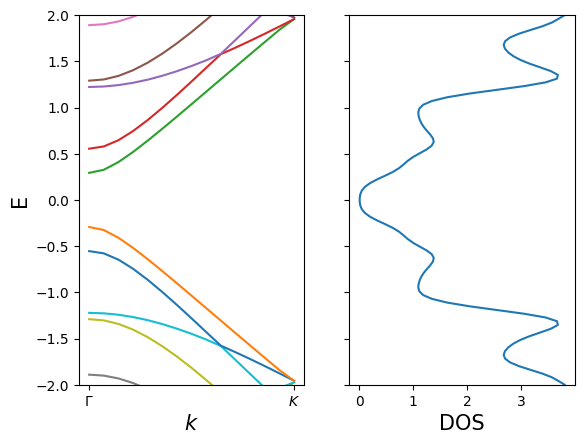

In [ ]:
energies = np.linspace(-2, 2, num=100)
fig, axes = plot_dos_band(electrode, 100, energies)
minmax = 2
axes[0].set(ylim=(-minmax, minmax));

## Benchmarking

loop: 100%|██████████| 4/4 [00:43<00:00, 10.77s/it]


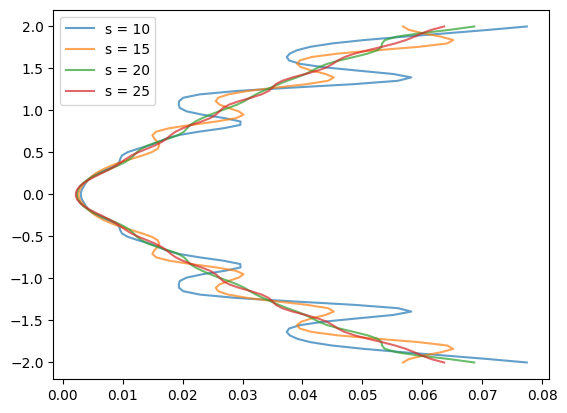

In [71]:
from tqdm import tqdm
sizes = [10, 15, 20, 25]
fig, axes = plt.subplots()
for s in tqdm(sizes, desc="loop"):
    flake = sisl.geom.graphene_flake(s)
    H = hamiltonian(flake)
    es = H.eigenstate()
    pdos = es.PDOS(E=energies).squeeze()
    axes.plot(pdos[0], energies, label=f"{s = }", alpha=0.7)

axes.legend()

In [ ]:
## LDOS from self-energies

# Make and plot reduced device

In [24]:
device, lr_idx = build_reduced_device(ribbon, electrode, repeat=3)

# print(ribbon.nsc)
# print(device.nsc)
# print(hamiltonian(device).nsc)

# plotting
atoms_style = mark_electrode(lr_idx)

# print(f"num atoms: {len(device)}")
plot_with_center(device, atoms_style=atoms_style)

       Initial number of atoms: 1344
 Atoms after removing overlaps: 960


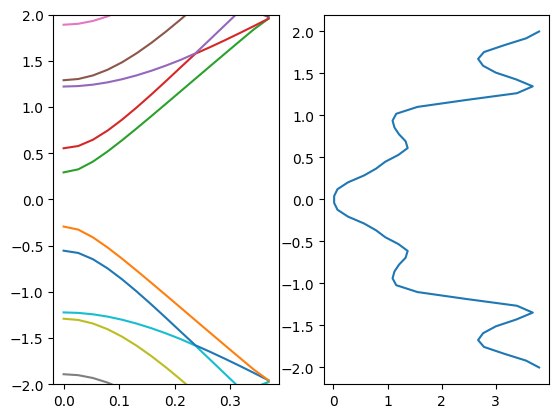

In [44]:
E = np.linspace(-2, 2, num=50)

dos, bs, lk = electrode_dos(hamiltonian(electrode), 100, E)
fig, axes = plt.subplots(1, 2)

axes[0].plot(lk, bs)
axes[0].set(ylim=(-2, 2))
axes[1].plot(dos, E)

In [26]:
view(device.to.ase())

<Popen: returncode: None args: ['/home/bastian/projects/QuantumTwistingMicro...>

# Compute LDOS for different k points and energies

In [28]:
RECOMPUTE = False
USE_PARALLEL = False
file_name = "recent_structure_2.npz"
if RECOMPUTE:
    Nk = 1
    energies = np.linspace(-3, 3, num=100)
    if USE_PARALLEL:
        all_ldos = multi_LDOS_parallel(device=device, electrode=electrode, 
                                    lr_indices=lr_idx, 
                                    energies=energies, Nk=Nk, form="csc")
    else:
        all_ldos = multi_LDOS(device, electrode, 
                              lr_indices=lr_idx, 
                              energies=energies, Nk=Nk, form="csc")
    np.savez(file_name, device=device, ldos=all_ldos, E=energies, allow_pickle=True)
else:
    data = np.load(file_name, "r+")
    all_ldos = data["ldos"]
    energies = data["E"]
        
# print(all_ldos)
        
H_0 = hamiltonian(electrode)
Nk = 1
dos_electrode, *_ = electrode_dos(H_0, 100, energies)
H_D = hamiltonian(device)
kpts = sisl.MonkhorstPack(H_D, [1,Nk,1]).k
pristine = sisl.geom.graphene_flake(30)

# bz = sisl.MonkhorstPack(hamiltonian(pristine), [1,Nk,1])
H_pristine = hamiltonian(pristine)
es = H_pristine.eigenstate()
pdos = es.PDOS(energies).squeeze()



def plot_ldos(kidx, site, fixed_scale):
    
    fig, axes = plt.subplots(1,2, sharey=True)
    
    
    axes[0].plot(all_ldos[kidx, :, site], energies, label="Reduced")
    axes[0].plot(pdos[0], energies, label="Pristine")
    if fixed_scale:
        ymin, ymax = np.min(all_ldos), np.max(all_ldos)
        axes.set_xlim(-ymax*0.1, ymax*1.01)
    axes[0].set_xlabel("LDOS/PDOS")
    axes[0].set_ylabel("E")
    
    axes[1].plot(dos_electrode, energies)
    
    axes[0].legend()
    
    
from utils.structure import find_nearest_atoms

valid_atom = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
print(valid_atom)
    

options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
ks = ipywidgets.Dropdown(options=options, description="k")
static = ipywidgets.fixed(all_ldos)
# sites = ipywidgets.IntSlider(min=left_idx[0].max()+1, max=right_idx[0].min()-1, value=left_idx[0].min(), description="Site")
sites = ipywidgets.Dropdown(options=valid_atom, description="Site")

scale = ipywidgets.Checkbox(value=False, description="Use fixed scale", indent=True)
interact(plot_ldos, kidx=ks, site=sites, fixed_scale=scale)




[220 228 211 235 219 227]


interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(kidx, site, fixed_scale)>

loop:   0%|          | 0/5 [00:00<?, ?it/s]

loop: 100%|██████████| 5/5 [01:51<00:00, 22.25s/it]


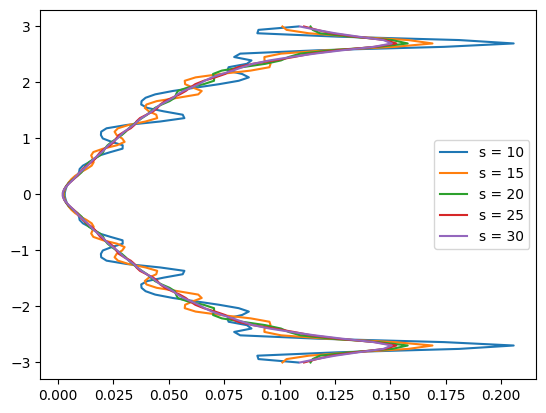

In [ ]:
view(pristine.to.ase())
print(len(pristine))
pristine.plot(axes="xy")


1536


In [ ]:
from utils.energies import lr_energies, add_lr_energies
from sisl.physics import RecursiveSI
# 1) pick small device/kvec/energies
energies = np.linspace(-1, 1, 7)
kvec = [0,0,0]   # if Nk=1

H_D = hamiltonian(device)
Hk = H_D.Hk(k=kvec, format="csc", dtype=complex)
Sk = H_D.Sk(k=kvec, format="csc", dtype=complex)

# serial dense reference:
ldos_ref = []
for E in energies:
    En = E + 1j*1e-5
    SE_L, SE_R = lr_energies(electrode=RecursiveSI(hamiltonian(electrode), infinite="+A"), En=En, kvec=kvec)
    Hk_e = add_lr_energies(Hk.copy(), (SE_L, SE_R), (left_idx, right_idx))
    invG = Sk * En - Hk_e
    G = np.linalg.inv(invG.toarray())
    ldos_ref.append( -(np.imag(np.diag(G))) / np.pi )
ldos_ref = np.vstack(ldos_ref)

# parallel
ldos_par = multi_LDOS_parallel(device, electrode, (left_idx, right_idx), energies=energies, Nk=1, show_progress=False)

print("shape ref:", ldos_ref.shape, "shape par:", ldos_par.shape)
print("max abs diff:", np.max(np.abs(ldos_par[0] - ldos_ref)))
print("first 10 elements ref:", ldos_ref[0][:10])
print("first 10 elements par:", ldos_par[0][:10])


shape ref: (7, 648) shape par: (1, 7, 648)
max abs diff: 0.1905347755772712
first 10 elements ref: [0.05322758 0.01134092 0.02459384 0.03514324 0.05219196 0.03521048
 0.03900108 0.05498929 0.03463173 0.02028574]
first 10 elements par: [[-2.61587561e-02 -6.27431455e-03  2.84887740e-02 ... -6.56030725e-03
  -3.06319836e-02  3.88782225e-02]
 [-1.10719808e-02 -4.66522600e-03  1.50148782e-02 ... -4.73093066e-03
  -9.83842026e-03  1.18604632e-02]
 [-4.12259087e-06 -1.71771584e-06  6.01048461e-06 ...  7.36576965e-06
   1.06374020e-05 -1.52844807e-05]
 ...
 [ 4.90391079e-05  1.34100180e-05 -6.04927690e-05 ...  1.79132919e-05
   1.93803049e-05 -3.18138699e-05]
 [ 6.84644390e-02  2.30180609e-02 -8.05152561e-02 ...  3.47793471e-02
   6.81312218e-02 -9.28193178e-02]
 [ 6.53110087e-02 -6.68949405e-03 -4.93450795e-02 ...  9.21264033e-02
  -6.26761634e-02  1.78335672e-02]]


### Profiling

In [ ]:
# %lprun -f transport -s -u 1e-3 LDOS(PBC_ham, energies)